<a href="https://colab.research.google.com/github/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIOPAL Project**
# **Title of project: Among adults aged 20-80, using data collected from the 2007-2008 to 2015-2016 NHANES cycles, Does depression predict higher fasting glucose, HbA1c, oral glucose tolerance test and fasting insulin biomarkers?**

## Group members and contributions:
| Member | Student Name | Student Number | Contribution to the project |
|--------|--------------|------------------|--------------------------------------------------------
|1| Sreya |  S10240940C  | (3) Logistic Regression analysis|
|2| Benetta | S10268028F | (2) Data exploration |
| 3| Tian  Yu | S10240966C | (1) Data preparation and (4) predictive analysis using XGBoost |

### Link to GitHub repository:
### Link to Google Colab:



# **1. Data loading and preparation**

### **1.1 Importing of libraries, loading of functions and preliminary cleaning**


In [1]:
import pandas as pd
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# -----------------------------
# Generic data loader (EDITED)
# -----------------------------

TINY_THRESHOLD = 1e-6

def load_data(file_prefix, columns, years, cycles, dtype_map=None):
    urls = [
        f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        for y, c in zip(years, cycles)
    ]

    df_list = []
    for url in urls:
        try:
            df = pd.read_sas(url)

            use_cols = [col for col in columns if col in df.columns]
            df = df[use_cols].copy()

            # Force numeric where possible
            for col in use_cols:
                df[col] = pd.to_numeric(df[col], errors="coerce")

            # Clean tiny floating-point artifacts
            for col in df.columns:
                if pd.api.types.is_float_dtype(df[col]):
                    df[col] = df[col].apply(
                        lambda x: 0 if pd.notna(x) and abs(x) < TINY_THRESHOLD else x
                    )

            # Cast dtypes if provided
            if dtype_map is not None:
                df = df.astype(dtype_map)

            df_list.append(df)

        except Exception as e:
            print(f"Could not load {url}: {e}")

    if not df_list:
        return pd.DataFrame(columns=columns)

    return pd.concat(df_list, ignore_index=True)

In [3]:
# -----------------------------
# NHANES cycles (OGTT available)
# -----------------------------
years  = ["2007", "2009", "2011", "2013", "2015"]
cycles = ["E", "F", "G", "H", "I"]

# -----------------------------
# Load datasets (with casting)
# -----------------------------
df_demo = load_data(
    "DEMO",
    ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "INDFMPIR"],
    years, cycles,
    dtype_map={
        "SEQN": "int64",
        "RIDAGEYR": "Int64",
        "RIAGENDR": "Int64",
        "RIDRETH1": "Int64",
        "INDFMPIR": "float64"
    }
)

df_phq = load_data(
    "DPQ",
    ["SEQN"] + [f"DPQ0{i}0" for i in range(1, 10)],
    years, cycles,
    dtype_map={"SEQN": "int64"}
)

df_diq = load_data(
    "DIQ",
    ["SEQN", "DIQ160", "DIQ170"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DIQ160": "Int64", "DIQ170": "Int64"}
)

df_smq = load_data(
    "SMQ",
    ["SEQN", "SMQ020"],
    years, cycles,
    dtype_map={"SEQN": "int64", "SMQ020": "Int64"}
)

df_bmx = load_data(
    "BMX",
    ["SEQN", "BMXWAIST", "BMXBMI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "BMXWAIST": "float64", "BMXBMI": "float64"}
)

df_diet = load_data(
    "DR1TOT",
    ["SEQN", "DR1TKCAL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DR1TKCAL": "float64"}
)

df_paq = load_data(
    "PAQ",
    ["SEQN", "PAD680"],
    years, cycles,
    dtype_map={"SEQN": "int64", "PAD680": "float64"}
)

df_ldl = load_data(
    "TRIGLY",
    ["SEQN", "LBDLDL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDLDL": "float64"}
)

df_glu = load_data(
    "GLU",
    ["SEQN", "LBDGLUSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLUSI": "float64"}
)

df_hba1c = load_data(
    "GHB",
    ["SEQN", "LBXGH"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBXGH": "float64"}
)

df_ogtt = load_data(
    "OGTT",
    ["SEQN", "LBDGLTSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLTSI": "float64"}
)

df_ins = load_data(
    "INS",
    ["SEQN", "LBDINSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

# Insulin for cycles E, F, G from GLU file
df_ins_efg = load_data(
    "GLU",
    ["SEQN", "LBDINSI"],
    years=["2007", "2009", "2011"],
    cycles=["E", "F", "G"],
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

df_ins = pd.concat([df_ins, df_ins_efg], ignore_index=True)

# -----------------------------
# Merge everything
# -----------------------------
dfs = [
    df_demo, df_phq, df_diq, df_smq, df_bmx,
    df_diet, df_paq, df_ldl,
    df_glu, df_hba1c, df_ogtt, df_ins
]

df = reduce(lambda left, right: pd.merge(left, right, on="SEQN", how="left"), dfs)

# -----------------------------
# Final dataset ready for modeling
# -----------------------------
print(df.shape)
df.head()


Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/INS_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/INS_G.xpt: HTTP Error 404: Not Found
(50588, 26)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,...,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI
0,41475,62,2,5,1.83,1.0,0.0,1.0,1.0,1.0,...,2,156.3,58.04,1598.0,720.0,NaN,NaN,5.7,NaN,NaN
1,41476,6,2,5,5.00,NaN,NaN,NaN,NaN,NaN,...,<NA>,52.7,15.18,2093.0,NaN,NaN,NaN,NaN,NaN,NaN
2,41477,71,1,3,1.50,0.0,0.0,0.0,0.0,0.0,...,1,109.5,30.05,914.0,240.0,NaN,NaN,9.5,NaN,NaN
3,41478,1,2,3,0.66,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,1148.0,NaN,NaN,NaN,NaN,NaN,NaN
4,41479,52,1,1,2.20,0.0,0.0,0.0,0.0,0.0,...,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.6


Indication of 'missingness' of the uncleaned df

In [4]:
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,9.027833
DPQ010,47.534989
DPQ020,47.544872
DPQ030,47.548826
DPQ040,47.556733
DPQ050,47.556733


### **1.2 Data cleaning**

Removal of data for those that responded Don't know or refused to respond

In [5]:
## to find the value used to code for don't know or refused, the max value is found
df.max()

,0
SEQN,93702.0
RIDAGEYR,80.0
RIAGENDR,2.0
RIDRETH1,5.0
INDFMPIR,5.0
DPQ010,9.0
DPQ020,9.0
DPQ030,9.0
DPQ040,9.0
DPQ050,9.0


Using the max values from the previous step,
- DPQ010 - DPQ090 -> coded as 7/9
- DIQ160, DIQ170 -> coded as 7/9
- SMQ020 -> coded as 7/9
- PAD680 -> coded as 7777/9999

These responses are cleaned out below:


In [6]:
# -----------------------------
# DPQ (PHQ-9 items)
# -----------------------------
dpq_cols = [f"DPQ0{i}0" for i in range(1, 10)]
dpq_map = {7: np.nan, 9: np.nan}

for col in dpq_cols:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# DIQ160-170, SMQ020
# -----------------------------
for col in ["DIQ160", "DIQ170", "SMQ020"]:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# PAD680 (sedentary minutes)
# -----------------------------
pad_map = {7777: np.nan, 9999: np.nan}

if "PAD680" in df.columns:
    df["PAD680"] = df["PAD680"].replace(pad_map)

# -----------------------------
# Sanity check: new max values
# -----------------------------
check_cols = dpq_cols + ["PAD680"]

for col in check_cols:
    if col in df.columns:
        print(f"Max value in {col}: {df[col].max()}")


Max value in DPQ010: 3.0
Max value in DPQ020: 3.0
Max value in DPQ030: 3.0
Max value in DPQ040: 3.0
Max value in DPQ050: 3.0
Max value in DPQ060: 3.0
Max value in DPQ070: 3.0
Max value in DPQ080: 3.0
Max value in DPQ090: 3.0
Max value in PAD680: 1380.0


PHQ-9 total scores are computed, DPQ010-DPQ090 columns are removed here.

In [7]:
# -----------------------------
# Compute PHQ-9 total score
# -----------------------------

# Keep only rows with complete PHQ-9 data
df = df.dropna(subset=dpq_cols)

# Sum PHQ-9 items
df["PHQ9_total"] = df[dpq_cols].sum(axis=1)

# Cast to int (PHQ-9 is discrete 0–27)
df["PHQ9_total"] = df["PHQ9_total"].astype(int)

# -----------------------------
# Remove DPQ item columns
# -----------------------------
df = df.drop(columns=dpq_cols)

# -----------------------------
# Check
# -----------------------------
print(df[["PHQ9_total"]].describe())


         PHQ9_total
count  26392.000000
mean       3.276978
std        4.348256
min        0.000000
25%        0.000000
50%        2.000000
75%        5.000000
max       27.000000


Particpants younger than 20 or older than 79 are filtered out here.
- 80 is used to code for participants 80 years old and older in certain cycles, hence 80 is excluded and 79 is incuded

In [8]:
## Filter out participants less than 20 years old or more than 80 years old
df = df[(df["RIDAGEYR"] >= 20) & (df["RIDAGEYR"] <= 79)]
df.shape

(23529, 18)

In [9]:
## Missingness after filtering
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,8.202644
DIQ160,14.956012
DIQ170,12.835225
SMQ020,0.059501
BMXWAIST,2.779549
BMXBMI,0.837265


Any rows with missing data are removed and put into a new dataframe, ``` df_model ```, which will be used for logistic regression models



In [10]:
# Clean out all NaN rows
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')
df_model

Initial shape: (23529, 18), shape after cleaning: (6929, 18)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
4,41479,52,1,1,2.20,2,2,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.60,0
10,41485,30,2,2,1.01,2,2,2,89.7,25.99,1308.0,120.0,119.0,5.384,5.5,4.052,51.24,3
11,41486,61,2,1,1.75,2,2,2,97.0,31.21,1547.0,480.0,110.0,6.828,6.1,12.656,127.02,2
12,41487,27,1,5,5.00,2,2,2,82.9,23.44,1790.0,600.0,105.0,5.995,5.0,7.771,71.52,0
14,41489,40,2,1,2.15,2,2,2,109.2,36.59,2091.0,480.0,106.0,5.495,5.4,6.828,101.58,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,93643,64,2,4,0.20,2,2,1,111.3,41.10,956.0,60.0,166.0,6.450,6.5,10.200,81.90,0
50540,93655,38,1,3,1.15,2,2,1,92.0,24.00,2004.0,240.0,191.0,5.940,5.7,5.830,33.72,0
50548,93663,43,1,1,1.07,2,2,2,94.6,24.10,3892.0,180.0,125.0,5.440,5.0,8.050,51.90,0
50549,93664,39,1,1,4.93,1,2,2,92.5,26.00,2305.0,120.0,114.0,6.160,5.4,6.050,45.06,5


Descriptive statistics for df_model

In [11]:
df_model.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
count,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000
mean,66842.801414,45.980372,1.500794,2.97229,2.584231,1.940395,1.874585,1.556935,97.798355,28.609717,2163.735460,350.033915,116.750469,5.591902,5.477832,6.478185,73.989196,2.950931
std,15175.322531,16.254717,0.500035,1.147135,1.652119,0.23677,0.331213,0.496784,15.841507,6.561219,986.391053,201.927639,34.635606,0.896687,0.545755,2.646072,61.146078,4.037557
min,41479.000000,20.0,1.0,1.0,0.000000,1.0,1.0,1.0,61.100000,15.020000,89.000000,0.000000,15.000000,3.164000,3.600000,1.277000,0.840000,0.000000
25%,53732.000000,32.0,1.0,2.0,1.110000,2.0,2.0,1.0,86.600000,24.000000,1500.000000,180.000000,93.000000,5.107000,5.200000,4.829000,36.720000,0.000000
50%,65988.000000,45.0,2.0,3.0,2.210000,2.0,2.0,2.0,96.200000,27.600000,1998.000000,300.000000,114.000000,5.495000,5.400000,5.940000,57.300000,2.000000
75%,80312.000000,60.0,2.0,4.0,4.260000,2.0,2.0,2.0,107.000000,31.800000,2636.000000,480.000000,138.000000,5.884000,5.700000,7.383000,91.140000,4.000000
max,93695.000000,79.0,2.0,5.0,5.000000,2.0,2.0,2.0,172.500000,70.100000,13687.000000,1200.000000,375.000000,22.100000,13.700000,30.100000,999.600000,27.000000


Check that there are no missing data left (delete before submission)

In [12]:
df_model.isnull().sum()/len(df)*100

,0
SEQN,0.0
RIDAGEYR,0.0
RIAGENDR,0.0
RIDRETH1,0.0
INDFMPIR,0.0
DIQ160,0.0
DIQ170,0.0
SMQ020,0.0
BMXWAIST,0.0
BMXBMI,0.0


### **1.3 Data preparation and classification**

HbA1c is classified using the criteria below:

- 6.5% or higher = diabetic
- 5.7% to 6.% = prediabetic
- below 5.7% = normal

In [13]:
df["HbA1c_cat"] = pd.cut(
    df["LBXGH"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting glucose is classified using the criteria below:

- 7mmol/L or higher = diabetic
- 5.6 to 6.9mmol/L = prediabetic
- less than 5.6mmol/L = normal

In [14]:
df["FPG_cat"] = pd.cut(
    df["LBDGLUSI"],
    bins=[-np.inf, 5.6, 7.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

OGTT glucose is classified using the criteria below:

- 11.0mmol/L or higher = diabetic
- 7.8 to 11.0mmol/L = prediabetic
- less than 7.8mmol/L = normal

In [15]:
df["OGTT_cat"] = pd.cut(
    df["LBDGLTSI"],
    bins=[-np.inf, 7.8, 11.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting insulin is classified using the criteria below:

- above 78.8 = abnormally high
- 15.1-78.8 pmol/L = normal
- below 15.1 = abnormally low

In [16]:
df["Insulin_cat"] = pd.cut(
    df["LBDINSI"],
    bins=[-np.inf, 15.1, 78.8, np.inf],
    labels=["abnormally_low", "normal", "abnormally_high"],
    right=False
)

PHQ-9 data is classified using the criteria below:

- 0-4 = no/minimal depression
- 5-9 = mild
- 10-14 = moderate
- 15-19 = moderately severe
- 20-27 = severe

In [17]:
df["PHQ9_cat"] = pd.cut(
    df["PHQ9_total"],
    bins=[-np.inf, 5, 10, 15, 20, np.inf],
    labels=[
        "no_minimal",
        "mild",
        "moderate",
        "moderately_severe",
        "severe"
    ],
    right=False
)

BMI is classified using the criteria below:

- below 18.5kg/m^2 = underweight
- 18.5 - 22.9kg/m^2 = normal
- 23.0 - 27.4kg/m^2 = overweight
- more than or equal to 27.5kg/m^2 = obese

In [18]:
df["BMI_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[-np.inf, 18.5, 23.0, 27.5, np.inf],
    labels=["underweight", "normal", "overweight", "obese"],
    right=False
)

the poverty income ratio is classified using the criteria below:

- below 1.0 = below poverty line
- 1.0 to 1.99 = borderline poverty
- above 2.0 = not in poverty

In [19]:
df["PIR_cat"] = pd.cut(
    df["INDFMPIR"],
    bins=[-np.inf, 1.0, 2.0, np.inf],
    labels=["below_poverty", "borderline_poverty", "not_poor"],
    right=False
)

Waist circumference is classified using the criteria below:

- above 94cm for men = unhealthy
- above 80cm for women = unhealthy

In [20]:
df["Waist_cat"] = np.where(
    ((df["RIAGENDR"] == 1) & (df["BMXWAIST"] > 94)) |
    ((df["RIAGENDR"] == 2) & (df["BMXWAIST"] > 80)),
    "unhealthy",
    "healthy"
)

Sedentary time (hours/day) is classified into the following categories, Less than 4 hrs, 4–8 hrs, 8–12 hrs, 12+ hrs:

In [21]:
df["Sedentary_cat"] = pd.cut(
    df["PAD680"] / 60,
    bins=[-np.inf, 4, 8, 12, np.inf],
    labels=["<4hrs", "4-8hrs", "8-12hrs", "12+hrs"],
    right=False
)

Participants are binned into 10 year age groups (e.g 30-40):

In [22]:
df["Age_cat"] = pd.cut(
    df["RIDAGEYR"],
    bins=range(20, 90, 10),
    right=False
)

LDL cholesterol is classified using the criteria below:

- Normal: below 100
- Elevated: 100-129
- Borderline high: 130-159
- High: 160-189
- Very high: 190 or higher

In [23]:
df["LDL_cat"] = pd.cut(
    df["LBDLDL"],
    bins=[-np.inf, 100, 130, 160, 190, np.inf],
    labels=["normal", "elevated", "borderline_high", "high", "very_high"],
    right=False
)

The values for categorical variables (speciifcally DIQ160, DIQ170 and SMQ020) are mapped onto the codes used in NHANES

In [24]:
# -----------------------------
# Gender
# -----------------------------
df["RIAGENDR"] = df["RIAGENDR"].map({1: "Male", 2: "Female"})

# -----------------------------
# Ethnicity / Race
# -----------------------------
df["RIDRETH1"] = df["RIDRETH1"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
})

# -----------------------------
# Family history of diabetes / prediabetes
# -----------------------------
df["DIQ170"] = df["DIQ170"].map({1: "Yes", 2: "No"})
df["DIQ160"] = df["DIQ160"].map({1: "Yes", 2: "No"})

# -----------------------------
# Smoking status
# -----------------------------
df["SMQ020"] = df["SMQ020"].map({1: "Yes", 2: "No"})



In [25]:
## Clean out NaN rows after classification
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')

Initial shape: (23529, 29), shape after cleaning: (6929, 29)


#### 1.3.1 Visualisation of the distribution of categories for converted categorical variables

In [26]:
# --------------------------------
# List of categorical variables
# --------------------------------
cat_vars = [
    "HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

# --------------------------------
# Plotting function (chunked)
# --------------------------------
def plot_categorical_distributions(df, variables, chunk_size=4):
    n_chunks = math.ceil(len(variables) / chunk_size)

    for i in range(n_chunks):
        chunk = variables[i * chunk_size:(i + 1) * chunk_size]
        fig, axes = plt.subplots(1, len(chunk), figsize=(5 * len(chunk), 4))

        if len(chunk) == 1:
            axes = [axes]

        for ax, col in zip(axes, chunk):
            counts = df[col].value_counts(dropna=False).sort_index()
            counts.plot(kind="bar", ax=ax)
            ax.set_title(col)
            ax.set_ylabel("Count")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


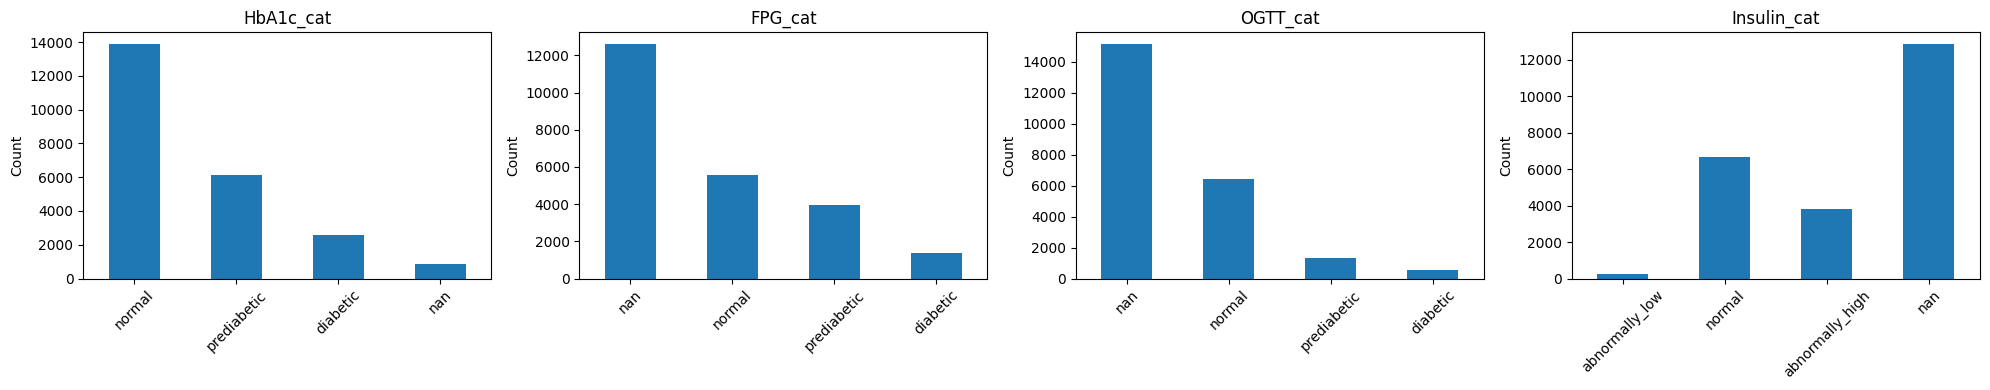

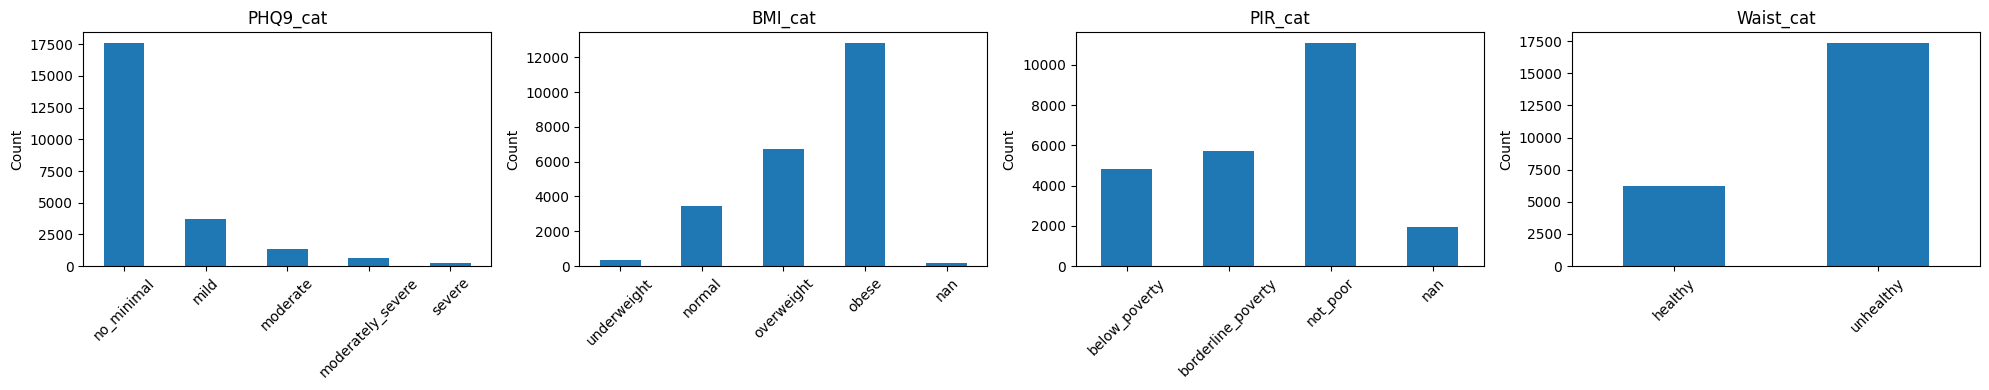

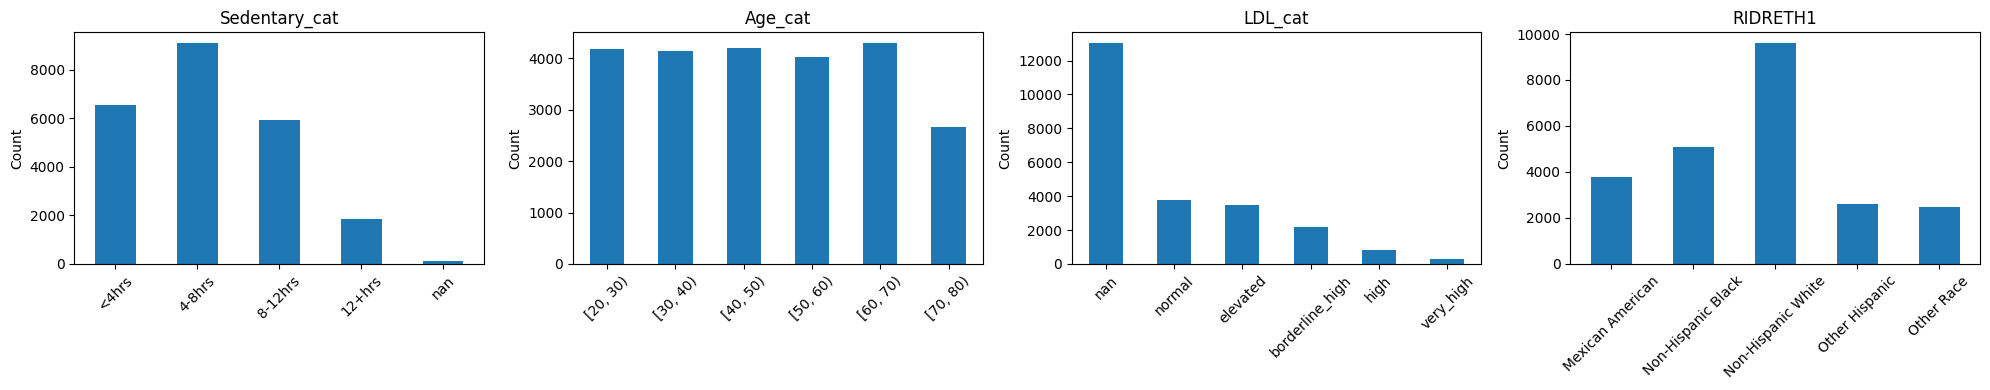

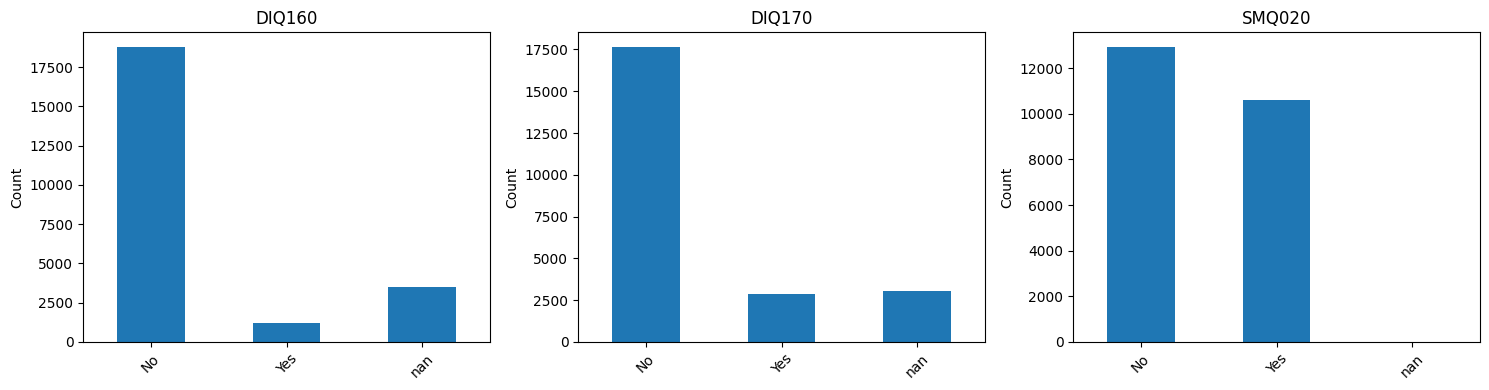

In [27]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


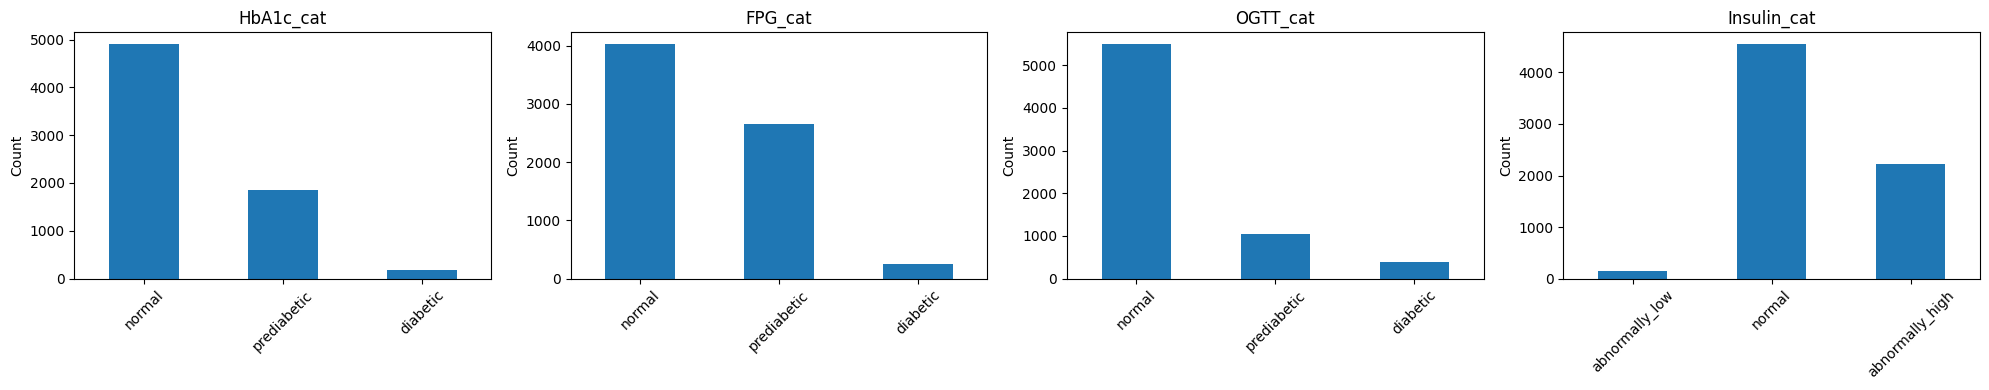

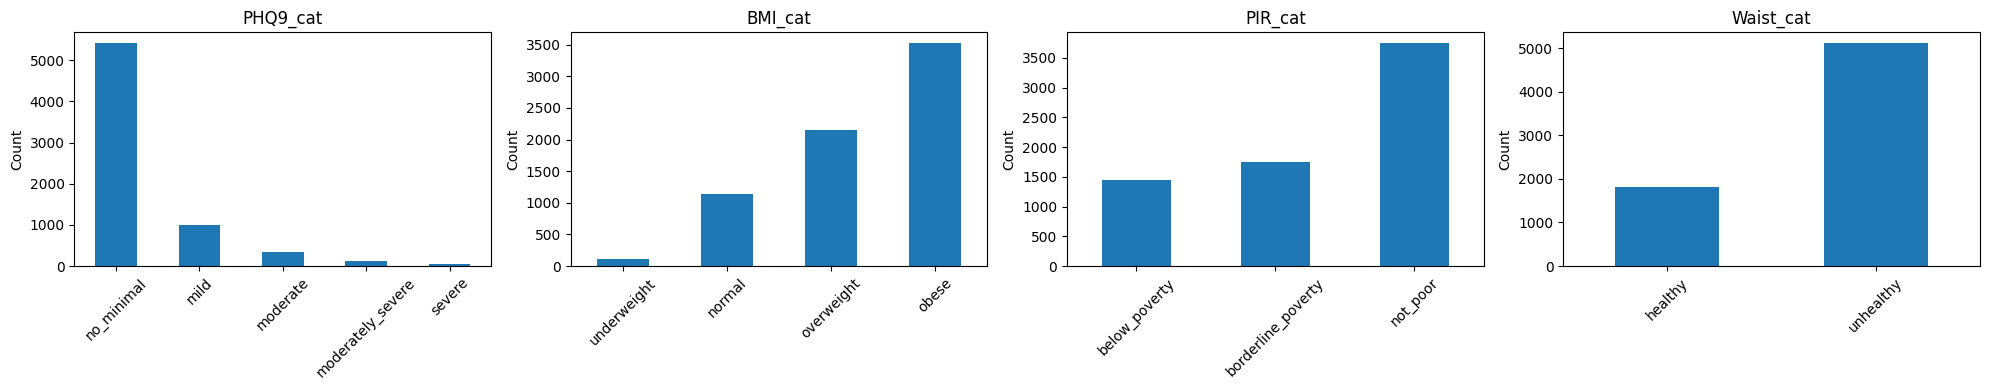

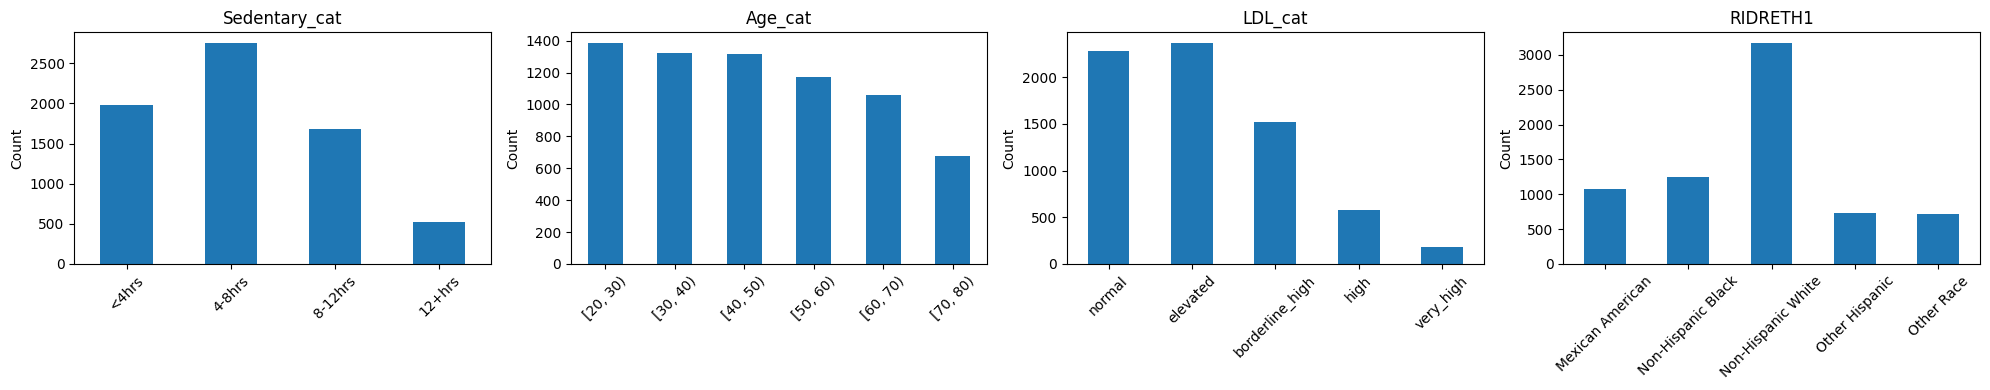

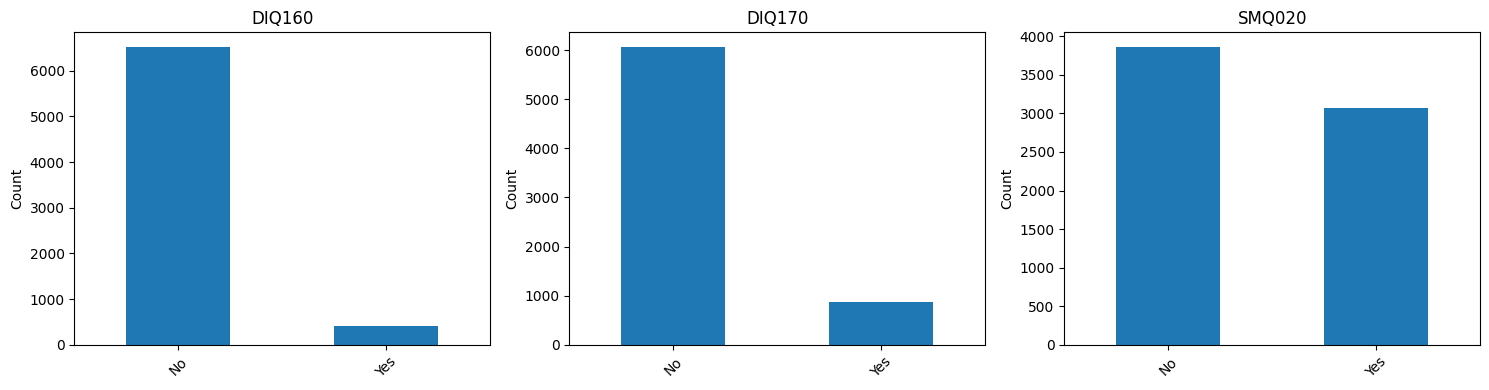

In [28]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)

Final ```df_model``` for logistic regression use

In [29]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].astype('category')


In [30]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6929 entries, 4 to 50580
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SEQN           6929 non-null   int64   
 1   RIDAGEYR       6929 non-null   Int64   
 2   RIAGENDR       6929 non-null   object  
 3   RIDRETH1       6929 non-null   object  
 4   INDFMPIR       6929 non-null   float64 
 5   DIQ160         6929 non-null   object  
 6   DIQ170         6929 non-null   object  
 7   SMQ020         6929 non-null   object  
 8   BMXWAIST       6929 non-null   float64 
 9   BMXBMI         6929 non-null   float64 
 10  DR1TKCAL       6929 non-null   float64 
 11  PAD680         6929 non-null   float64 
 12  LBDLDL         6929 non-null   float64 
 13  LBDGLUSI       6929 non-null   float64 
 14  LBXGH          6929 non-null   float64 
 15  LBDGLTSI       6929 non-null   float64 
 16  LBDINSI        6929 non-null   float64 
 17  PHQ9_total     6929 non-null   int64 

In [31]:
df_model

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,...,FPG_cat,OGTT_cat,Insulin_cat,PHQ9_cat,BMI_cat,PIR_cat,Waist_cat,Sedentary_cat,Age_cat,LDL_cat
4,41479,52,Male,Mexican American,2.20,No,No,No,95.4,27.56,...,prediabetic,normal,normal,no_minimal,obese,not_poor,unhealthy,<4hrs,"[50, 60)",elevated
10,41485,30,Female,Other Hispanic,1.01,No,No,No,89.7,25.99,...,normal,normal,normal,no_minimal,overweight,borderline_poverty,unhealthy,<4hrs,"[30, 40)",elevated
11,41486,61,Female,Mexican American,1.75,No,No,No,97.0,31.21,...,prediabetic,diabetic,abnormally_high,no_minimal,obese,borderline_poverty,unhealthy,8-12hrs,"[60, 70)",elevated
12,41487,27,Male,Other Race,5.00,No,No,No,82.9,23.44,...,prediabetic,normal,normal,no_minimal,overweight,not_poor,healthy,8-12hrs,"[20, 30)",elevated
14,41489,40,Female,Mexican American,2.15,No,No,No,109.2,36.59,...,normal,normal,abnormally_high,no_minimal,obese,not_poor,unhealthy,8-12hrs,"[40, 50)",elevated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,93643,64,Female,Non-Hispanic Black,0.20,No,No,Yes,111.3,41.10,...,prediabetic,prediabetic,abnormally_high,no_minimal,obese,below_poverty,unhealthy,<4hrs,"[60, 70)",high
50540,93655,38,Male,Non-Hispanic White,1.15,No,No,Yes,92.0,24.00,...,prediabetic,normal,normal,no_minimal,overweight,borderline_poverty,healthy,4-8hrs,"[30, 40)",very_high
50548,93663,43,Male,Mexican American,1.07,No,No,No,94.6,24.10,...,normal,prediabetic,normal,no_minimal,overweight,borderline_poverty,unhealthy,<4hrs,"[40, 50)",elevated
50549,93664,39,Male,Mexican American,4.93,Yes,No,No,92.5,26.00,...,prediabetic,normal,normal,mild,overweight,not_poor,healthy,<4hrs,"[30, 40)",elevated


# **2. Data exploration**

# **3. Logistic Regression (Associative modelling)**

# **4. XGBoost analysis (Predictive modelling)**